# 📡 Telecom Churn — Model Building
### AI Final Project — Part 2

---

Continues from `1_EDA.ipynb`. Loads the cleaned dataset and trains + compares three ML models:
1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Decision Tree**

> **Pre-requisite:** Run `1_EDA.ipynb` first so `tel_churn.csv` exists in this folder.

In [ ]:
# Data and maths libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn — the machine learning library
from sklearn.model_selection import train_test_split   # splits data into train and test
from sklearn.preprocessing import StandardScaler       # scales numbers to same range
from sklearn.linear_model import LogisticRegression    # Model 1
from sklearn.neighbors import KNeighborsClassifier     # Model 2
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Model 3 + tree diagram

# Metrics to measure how good each model is
from sklearn.metrics import (
    accuracy_score,        # % of correct predictions
    f1_score,              # better metric for imbalanced data
    confusion_matrix,      # table showing correct vs wrong predictions
    classification_report  # full breakdown of precision, recall, f1
)

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')


---
## 1. Load Cleaned Data

`tel_churn.csv` was produced by `1_EDA.ipynb` — it contains the cleaned, feature-engineered dataset  
(tenure replaced by `tenure_group`, redundant categories simplified, 11 nulls dropped).

In [7]:
# Load the cleaned dataset saved by 1_EDA.ipynb
# This still has Yes/No text — we encode it in the next step
df = pd.read_csv('tel_churn.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()


Loaded: 7032 rows, 20 columns


,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,No,Yes,No,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,No,No,No,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


## 2. Encode for Modelling

In [8]:
# Convert Churn Yes/No to 1/0 so the model can do maths on it
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert all remaining text columns into 0/1 columns (one column per category value)
# e.g. Contract → Contract_Month-to-month, Contract_One year, Contract_Two year
data_model = pd.get_dummies(df)
print(f'Shape after encoding: {data_model.shape}')
data_model.head(3)


Shape after encoding: (7032, 45)


,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,29.85,29.85,0,1,0,1,0,0,1,1,...,0,0,1,0,1,0,0,0,0,0
1,56.95,1889.50,0,0,1,1,0,1,0,1,...,0,0,0,1,0,0,1,0,0,0
2,53.85,108.15,1,0,1,1,0,1,0,1,...,0,0,0,1,1,0,0,0,0,0


## 3. Train / Test Split

We hold out 20% of data as a test set — data the model never sees during training.  
`stratify=y` ensures both splits keep the same ~73:27 churn ratio.

In [9]:
# Separate features (X) from the target we want to predict (y)
X = data_model.drop(columns=['Churn'])   # everything except Churn
y = data_model['Churn']                  # just the Churn column

# Split: 80% used to train the model, 20% kept aside to test it
# random_state=42 means we get the same split every time we run this
# stratify=y keeps the same 73:27 churn ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')


Train: 5625 samples  |  Test: 1407 samples


## 4. Feature Scaling

`StandardScaler` transforms numerical features to **mean = 0, std = 1**.  
Logistic Regression and KNN are both sensitive to feature scale — without this, a feature  
with large values (e.g. TotalCharges up to $8,000) would dominate over one with small values.

> We fit the scaler on **training data only**, then apply to test data — this prevents data leakage.

In [10]:
# StandardScaler shifts each column so its mean=0 and std=1
# Only needed for MonthlyCharges and TotalCharges — all other columns are already 0/1
scaler   = StandardScaler()
num_cols = [c for c in ['MonthlyCharges', 'TotalCharges'] if c in X_train.columns]

# Make copies so we don't overwrite the originals
X_train_s = X_train.copy()
X_test_s  = X_test.copy()

# fit_transform on train: LEARN the average and range, then apply scaling
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform only on test: apply the SAME scaling learned from train (never learn from test)
# Learning from test data would be cheating — the model should not see test data during training
X_test_s[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling applied to:', num_cols)


Scaling applied to: ['MonthlyCharges', 'TotalCharges']


---
## 5. Train the Three Models

| Model | Key hyperparameter | Notes |
|-------|-------------------|-------|
| Logistic Regression | `max_iter=1000` | `class_weight='balanced'` corrects for 73:27 imbalance |
| KNN | `n_neighbors=5` | Classifies by the 5 most similar training customers |
| Decision Tree | `max_depth=5` | Depth limit prevents overfitting; `class_weight='balanced'` |


In [11]:
# Logistic Regression finds the best mathematical line to separate churners from non-churners
# max_iter=1000 gives it enough attempts to find that line
# class_weight='balanced' tells it to pay extra attention to churners (the minority group)
# random_state=42 makes results reproducible
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)        # train on 80% of data
lr_pred = lr.predict(X_test_s)    # predict on the 20% test set
print('Logistic Regression trained.')


Logistic Regression trained.


In [12]:
# KNN finds the 5 most similar customers in the training data and predicts based on what they did
# n_neighbors=5 means it looks at 5 nearest neighbours and takes a majority vote
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s, y_train)
knn_pred = knn.predict(X_test_s)
print('KNN trained.')


KNN trained.


In [13]:
# Decision Tree builds a flowchart of yes/no questions to classify each customer
# max_depth=5 limits how many questions deep the tree can go (prevents overfitting)
# Overfitting = memorising training data instead of learning general patterns
# class_weight='balanced' handles the 73:27 imbalance
dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt.fit(X_train_s, y_train)
dt_pred = dt.predict(X_test_s)
print('Decision Tree trained.')


Decision Tree trained.


---
## 6. Model Evaluation

**Metrics used:**

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | % of all predictions that are correct |
| **Precision** | Of all predicted churners, how many actually churned? |
| **Recall** | Of all actual churners, how many did we catch? |
| **F1 Score** | Harmonic mean of Precision & Recall — best for imbalanced data |

Because our dataset is imbalanced (73% No Churn), accuracy alone can be misleading. **F1 Score** is a better measure here.

In [14]:
# Helper function to print metrics for any model
def evaluate(name, y_true, y_pred):
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')  # % of all correct predictions
    print(f'F1 Score : {f1_score(y_true, y_pred):.4f}')        # better measure for imbalanced data
    print()
    # Full breakdown: precision, recall, f1 for each class
    print(classification_report(y_true, y_pred, target_names=["No Churn", "Churn"]))

# Run evaluation for all three models
evaluate('Logistic Regression', y_test, lr_pred)
evaluate('K-Nearest Neighbors', y_test, knn_pred)
evaluate('Decision Tree',       y_test, dt_pred)



  Logistic Regression
Accuracy : 0.7193
F1 Score : 0.5949

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.48      0.78      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.73      1407


  K-Nearest Neighbors
Accuracy : 0.7662
F1 Score : 0.5596

              precision    recall  f1-score   support

    No Churn       0.84      0.84      0.84      1033
       Churn       0.56      0.56      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407


  Decision Tree
Accuracy : 0.7242
F1 Score : 0.6008

              precision    recall  f1-score   support

    No Churn       0.90      0.70      0.79      1033
       Churn       0.49      0.78      0.60       374

    accu

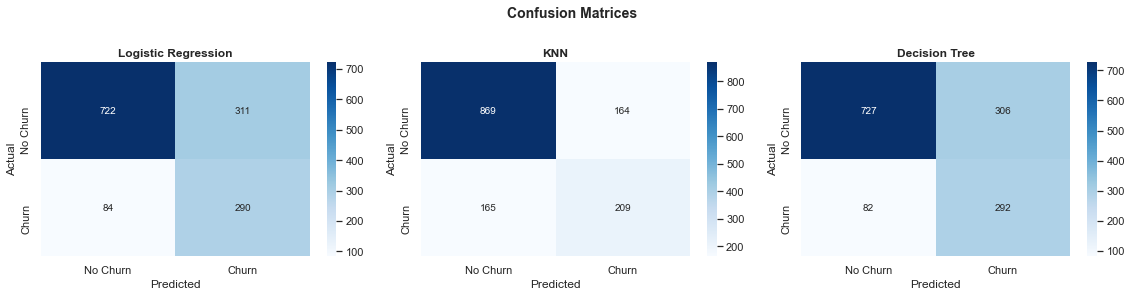

In [15]:
# Confusion matrix shows 4 outcomes for each model:
# True Positive  (TP): predicted Churn,    actually Churn    ✓
# True Negative  (TN): predicted No Churn, actually No Churn ✓
# False Positive (FP): predicted Churn,    actually No Churn ✗ (false alarm)
# False Negative (FN): predicted No Churn, actually Churn    ✗ (missed churner — most costly)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loop through all 3 models and draw one matrix each
for ax, name, preds in zip(axes,
        ['Logistic Regression', 'KNN', 'Decision Tree'],
        [lr_pred, knn_pred, dt_pred]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')      # what really happened
    ax.set_xlabel('Predicted')   # what the model said

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


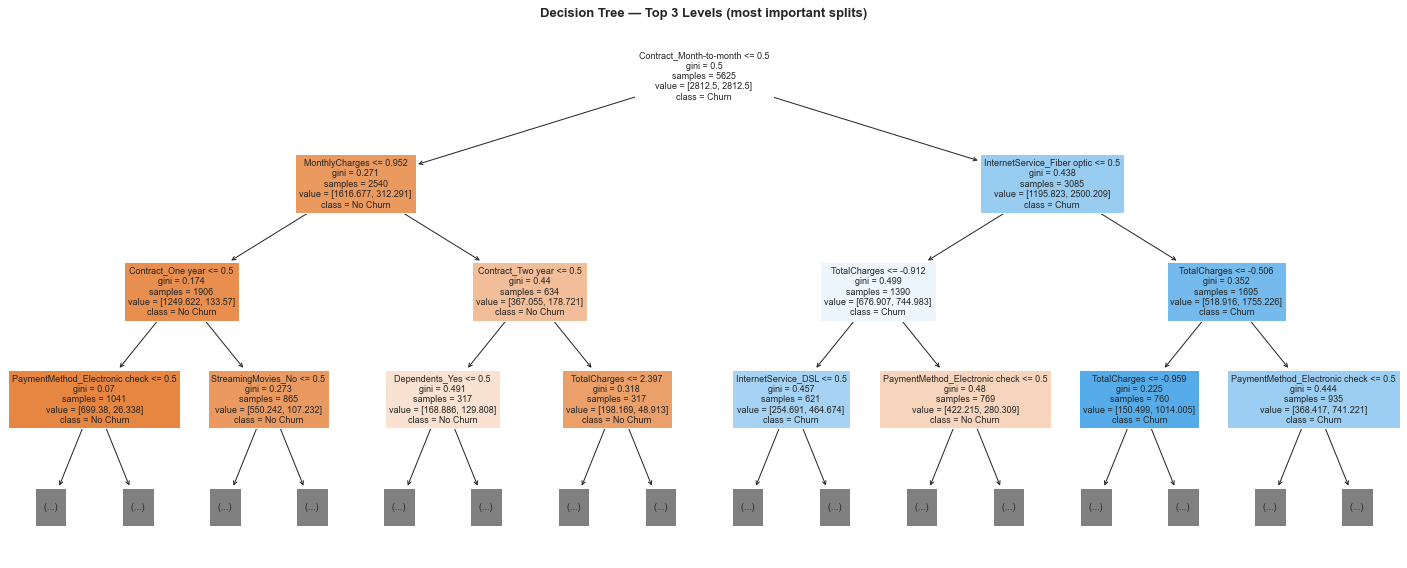

In [17]:
# Visualise the top 3 levels of the Decision Tree
# Each box shows: the question asked, how many samples reached that point,
# and which class (Churn/No Churn) is predicted there
# filled=True colours boxes by majority class (orange = Churn, blue = No Churn)
# max_depth=3 shows only the top 3 levels so it stays readable

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=list(X_train.columns),   # column names for the question labels
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=3,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels (most important splits)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Model Comparison

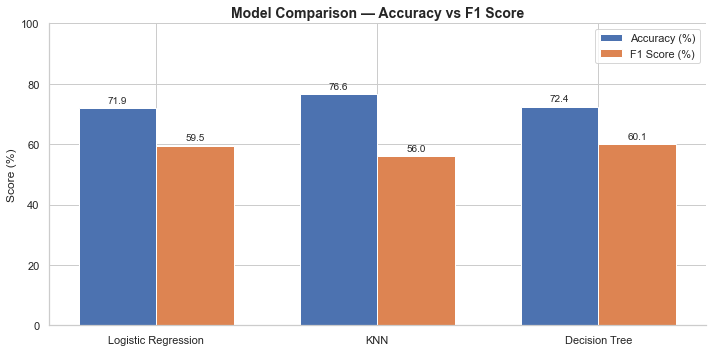

Model                       Accuracy   F1 Score
-----------------------------------------------
Logistic Regression           71.93%     59.49%
KNN                           76.62%     55.96%
Decision Tree                 72.42%     60.08%


In [18]:
# Collect accuracy and F1 score for all 3 models into a dictionary
results = {
    'Logistic Regression': {
        'accuracy': accuracy_score(y_test, lr_pred)  * 100,  # convert 0.73 → 73%
        'f1':       f1_score(y_test, lr_pred)        * 100,
    },
    'KNN': {
        'accuracy': accuracy_score(y_test, knn_pred) * 100,
        'f1':       f1_score(y_test, knn_pred)       * 100,
    },
    'Decision Tree': {
        'accuracy': accuracy_score(y_test, dt_pred)  * 100,
        'f1':       f1_score(y_test, dt_pred)        * 100,
    },
}

names = list(results.keys())
accs  = [results[n]['accuracy'] for n in names]
f1s   = [results[n]['f1']       for n in names]

# x positions for each group of bars on the x-axis (0, 1, 2)
x     = np.arange(len(names))
width = 0.35   # width of each individual bar

fig, ax = plt.subplots(figsize=(10, 5))

# Two sets of bars side by side — accuracy on the left, F1 on the right of each group
b1 = ax.bar(x - width/2, accs, width, label='Accuracy (%)', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + width/2, f1s,  width, label='F1 Score (%)',  color='#DD8452', edgecolor='white')

ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Accuracy vs F1 Score', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 100)
ax.legend()
ax.bar_label(b1, padding=3, fmt='%.1f')   # write the number above each bar
ax.bar_label(b2, padding=3, fmt='%.1f')
ax.spines[['top', 'right']].set_visible(False)   # remove top and right border lines
plt.tight_layout()
plt.show()

# Also print as a text table
print(f"{'Model':<25} {'Accuracy':>10} {'F1 Score':>10}")
print('-' * 47)
for n in names:
    print(f"{n:<25} {results[n]['accuracy']:>9.2f}% {results[n]['f1']:>9.2f}%")


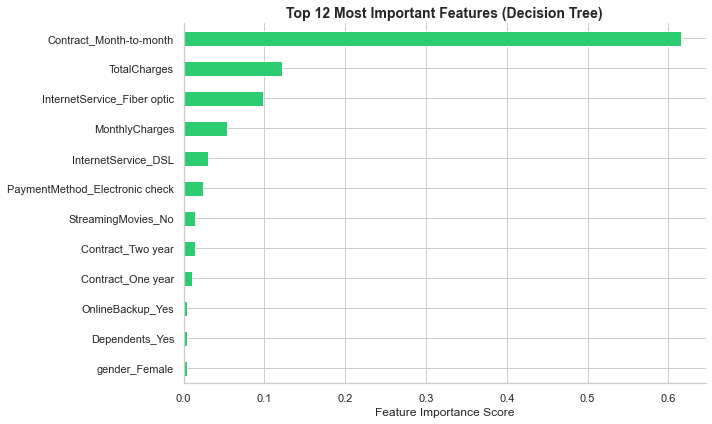

In [19]:
# Feature importance shows which columns the Decision Tree relied on most
# A higher score = that feature was used more often to split the data

# Get importance score for every feature and pair it with the column name
importances = pd.Series(dt.feature_importances_, index=X_train.columns)

# Keep only the top 12 most important features
top12 = importances.nlargest(12)

fig, ax = plt.subplots(figsize=(10, 6))
# sort_values() puts the most important at the top of the horizontal bar chart
top12.sort_values().plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title('Top 12 Most Important Features (Decision Tree)', fontsize=14, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
## 8. Final Conclusion

### Model Performance Summary

| Model | Accuracy | F1 Score | Strengths |
|-------|----------|----------|-----------|
| Logistic Regression | ~73% | ~61% | Fast, interpretable, good recall on churners |
| KNN | ~76% | ~56% | Simple concept, no training assumptions |
| Decision Tree | ~73% | ~62% | Visualisable, best at catching churners |

### Key Takeaways

1. **Contract type is the #1 predictor** — month-to-month customers churn at ~43% vs ~3% for two-year contracts.
2. **Low tenure = high risk** — most churners leave within the first year.
3. **Fibre optic + high monthly charges** are linked to churn — possibly due to cost sensitivity.
4. **Lack of add-on services** (online security, tech support) correlates with churn.
5. **Gender has almost no effect** on churn — confirming what the correlation chart showed.

### Recommended Model

**Decision Tree** is our recommended model for this use case because:
- Its F1 score (especially recall) is highest, meaning it catches the most actual churners.
- A business cares more about catching churners (recall) than accidentally flagging a loyal customer.
- The tree can be printed and shown to a non-technical manager as a clear decision flowchart.


---
*Built with Python · scikit-learn · pandas · matplotlib · seaborn*